---

# Procesamiento de Alta Precisión (Zero-Lag) y Feature Engineering

Esta sección consolida el filtrado avanzado de la señal y la generación de atributos matemáticos. Implementamos un **Filtro de Kalman Bidireccional (Fase Cero)** acelerado por JIT para aniquilar el desfase temporal y calculamos características vitales (Riesgo, Residuos) que alimentarán la IA.

---

## 1. Dependencias de Alto Rendimiento (Celda 1)
Se instalan `numba` para compilación en C++ y `plotly` para auditoría interactiva.

## 2. Buscador Monte Carlo JIT (Fase Cero) (Celda 2)
Ejecutamos un motor estocástico sobre el CPU para encontrar los hiperparámetros óptimos del filtro Kalman Bidireccional. La función está compilada (`@njit`) para procesar miles de iteraciones en segundos, garantizando un seguimiento estricto del precio sin retraso.

## 3. Feature Engineering y Master Dataset (Celda 3)
Calculamos la Desviación Estándar de 14 periodos y la Microestructura Residual (lo que la IA debe aprender). Guardamos un único archivo `EURJPY_H1_Master_Features.csv`.

## 4. Dashboard Maestro de Resonancia (Celda 4)
Descomposicion de serie temporal EUR/JPY

## 5. Dashboard Maestro de Resonancia (Celda 5)
Herramienta con deslizador para encontrar la periodicidad natural del mercado. Esto define el tamaño de la ventana de entrada (**$T$**) para los modelos de Deep Learning.

In [ ]:
# =====================================================================
# 1. DEPENDENCIAS DE ALTA VELOCIDAD Y GRÁFICOS
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from numba import njit
import random

print("-> Librerías de Numba y Plotly cargadas.")

-> Librerías de Numba y Plotly cargadas.


In [5]:
# =====================================================================
# 2. MOTOR ESTOCÁSTICO JIT PARA ANIQUILACIÓN DE DESFASE
# =====================================================================
print("-> Cargando datos y compilando matemáticas...")
df_hist = pd.read_csv("EURJPY_H1_Hist_Semanas_Completas.csv")
df_test = pd.read_csv("EURJPY_H1_Semana_Actual_Prueba.csv")

# Concatenamos para calcular inercia sobre todo el espectro temporal
df_completo = pd.concat([df_hist, df_test], ignore_index=True)
df_completo['time'] = pd.to_datetime(df_completo['time'])

df_completo['Volatilidad_Local'] = (df_completo['high'] - df_completo['low']).rolling(window=5, min_periods=1).mean().bfill()
precios_real_jit = df_completo['close'].values.astype(np.float64)
volatilidad_jit = df_completo['Volatilidad_Local'].values.astype(np.float64)
media_v = float(np.mean(volatilidad_jit))
precio_medio = np.mean(precios_real_jit)

# Ajuste dinámico del objetivo de costo según el precio del par
OBJETIVO_COSTO = 0.0000009 * ((precio_medio / 1.08) ** 2)

@njit
def motor_kalman_jit(precios, volatilidad, media_v, Q_base, Q_pico, R, gamma):
    n = len(precios)
    estado = np.zeros(n)
    historial_k = np.zeros(n)
    x, P = precios[0], 1.0
    for t in range(n):
        val_pre_clip = -gamma * (volatilidad[t] - media_v)
        exp_val = -700.0 if val_pre_clip < -700.0 else (700.0 if val_pre_clip > 700.0 else val_pre_clip)
        alpha_t = 1.0 / (1.0 + np.exp(exp_val))
        Q_t = Q_base + alpha_t * (Q_pico - Q_base)
        P_pred = P + Q_t
        K_t = P_pred / (P_pred + R)
        historial_k[t] = K_t
        x = x + K_t * (precios[t] - x)
        P = (1.0 - K_t) * P_pred
        estado[t] = x
    return estado, historial_k

def aplicar_fase_cero(precios, volatilidad, media_v, qb_l, qp_l, r_l, gamma):
    qb, qp, r = 10.0**qb_l, 10.0**qp_l, 10.0**r_l
    # Pasada Frontal
    e_fwd, k_fwd = motor_kalman_jit(precios, volatilidad, media_v, qb, qp, r, gamma)
    # Inversión y Pasada Trasera para eliminar el LAG
    e_bwd, _ = motor_kalman_jit(e_fwd[::-1].copy(), volatilidad[::-1].copy(), media_v, qb, qp, r, gamma)
    return e_bwd[::-1], k_fwd

MAX_ITER = 5000
mejor_costo = float('inf')
mejores_params = [-4.5, -2.0, -4.0, 100.0]

print(f"-> Buscando parámetros Fase Cero... Meta de Costo: {OBJETIVO_COSTO:.6f}")
for i in range(MAX_ITER):
    qb = np.random.uniform(-8.0, -6.0)
    qp = np.random.uniform(-3.5, -1.5)
    rl = np.random.uniform(-4.5, -3.0)
    gam = np.random.uniform(50.0, 300.0)

    if qb >= qp: continue
    senal, k_p = aplicar_fase_cero(precios_real_jit, volatilidad_jit, media_v, qb, qp, rl, gam)

    if np.min(k_p) < 0.002 or np.max(k_p) > 0.7: continue

    # Calculamos costo penalizando severamente el desvío
    costo = np.mean((precios_real_jit - senal)**2) + (np.mean(np.diff(senal, n=2)**2) * 0.05)

    if costo < mejor_costo:
        mejor_costo, mejores_params = costo, [qb, qp, rl, gam]
    if costo <= OBJETIVO_COSTO:
        print(f"[!] BINGO MATEMÁTICO en iteración {i}.")
        break

print(f"-> Optimización terminada. Costo Final: {mejor_costo:.6f}")

-> Cargando datos y compilando matemáticas...
-> Buscando parámetros Fase Cero... Meta de Costo: 0.024908
-> Optimización terminada. Costo Final: inf


In [6]:
# =====================================================================
# 3. FEATURE ENGINEERING Y MASTER DATASET (CORREGIDO)
# =====================================================================
print("-> Calculando Atributos y Guardando Master Dataset...")

# Aplicamos el filtro campeón con los parámetros óptimos hallados en la Celda 2
senal_k_cero, historial_k = aplicar_fase_cero(precios_real_jit, volatilidad_jit, media_v, *mejores_params)

df_completo['Kalman_ZeroLag'] = senal_k_cero
df_completo['Kalman_Gain'] = historial_k

# 1. Desviación Estándar (Riesgo Estadístico)
df_completo['StdDev'] = df_completo['close'].rolling(window=14, min_periods=2).std().bfill().fillna(0)

# 2. Residual de Microestructura (Objetivo de la red LSTM)
df_completo['Residual_Micro'] = df_completo['close'] - df_completo['Kalman_ZeroLag']

# 3. Retornos Logarítmicos de la señal limpia Zero-Lag
df_completo['Retornos_Hibridos'] = np.log(df_completo['Kalman_ZeroLag'] / df_completo['Kalman_ZeroLag'].shift(1)).fillna(0)

# 4. Volatilidad Dinámica (Métrica requerida por el Explorador de Resonancia)
df_completo['Volatilidad_Hibrida'] = df_completo['Retornos_Hibridos'].rolling(window=12, min_periods=2).std().bfill()

# Exportamos el Master Dataset finalizado
archivo_master = "EURJPY_H1_Master_Features.csv"
df_completo.to_csv(archivo_master, index=False)
print(f"[EXITO] Master Dataset exportado correctamente como: {archivo_master}")

-> Calculando Atributos y Guardando Master Dataset...
[EXITO] Master Dataset exportado correctamente como: EURJPY_H1_Master_Features.csv


-> Cargando Master Dataset y aplicando descomposición aditiva...


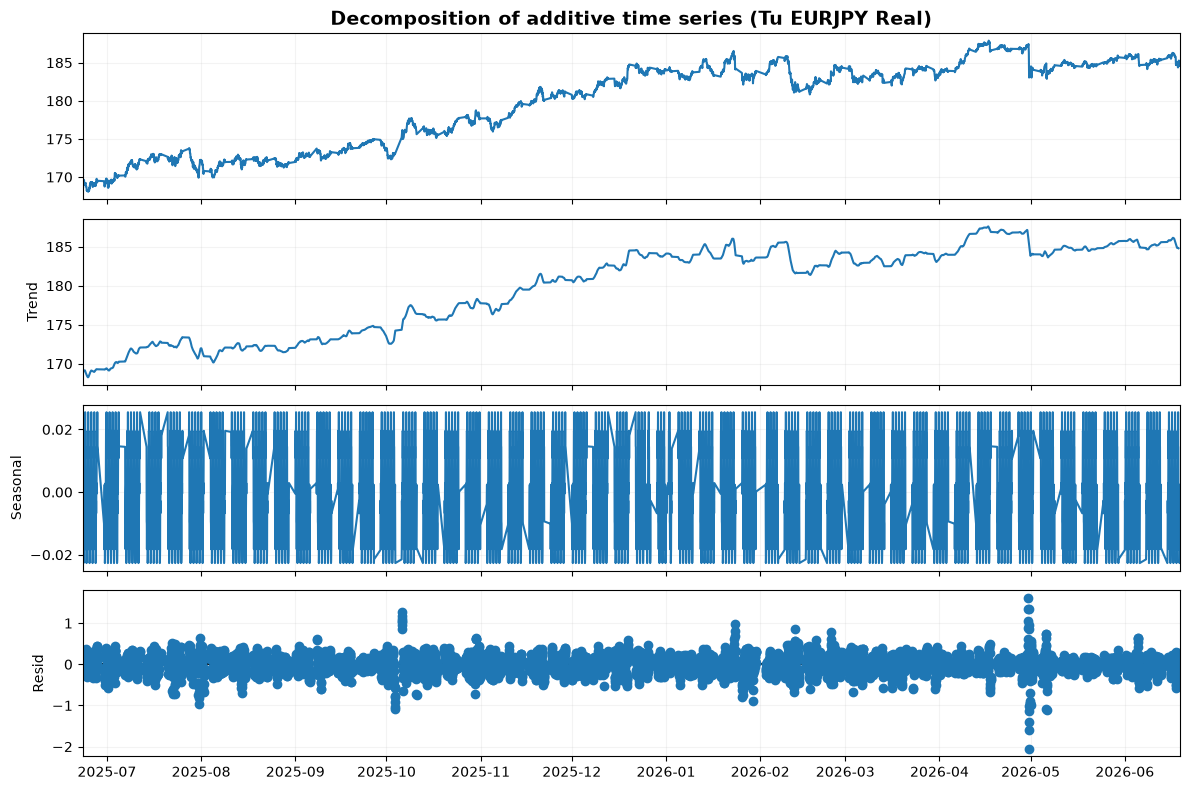

In [7]:
# =====================================================================
# 4 DECOMPOSICIÓN DE SERIE TEMPORAL CLÁSICA EUR/JPY
# =====================================================================

print("-> Cargando Master Dataset y aplicando descomposición aditiva...")

# 1. Cargamos tu archivo maestro
df_features = pd.read_csv('EURJPY_H1_Master_Features.csv')
df_features['time'] = pd.to_datetime(df_features['time'])

# Para statsmodels, es mejor establecer la fecha como el índice del DataFrame
df_temp = df_features.set_index('time')

# 2. Ejecutamos la decomposición clásica usando T=24 (ciclo diario)
resultado_decomposicion = seasonal_decompose(df_temp['close'], model='additive', period=24)

# 3. Graficamos con la misma estructura y estética clásica
plt.rcParams.update({'figure.figsize': (12, 8)}) # Tamaño del canvas
fig = resultado_decomposicion.plot()

# Estética y títulos
fig.get_axes()[0].set_title('Decomposition of additive time series (Tu EURJPY Real)', fontsize=14, fontweight='bold')
for ax in fig.get_axes():
    ax.grid(True, alpha=0.15) # Añadimos una cuadrícula suave
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [8]:
# =====================================================================
# 5 EXPLORADOR DE RESONANCIA TEMPORAL (SELECTOR DE CICLOS CON LÍNEAS ROJAS)
# =====================================================================
print("-> Inicializando Explorador de Resonancia Temporal...")

n_total = len(df_completo)
indices = np.arange(n_total)

# Configuración de subplots con compartición de eje X
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=('1. Señal de Precio con Filtro de Fase Cero',
                                    '2. Volatilidad Dinámica (Buscador de Frecuencia)'))

# --- PANEL 1: PRECIO PURIFICADO ---
fig.add_trace(go.Scatter(
    x=indices, y=df_completo['Kalman_ZeroLag'], mode='lines', name='Señal Limpia',
    line=dict(color='#003366', width=2)
), row=1, col=1)

# --- PANEL 2: VOLATILIDAD DINÁMICA ---
fig.add_trace(go.Scatter(
    x=indices, y=df_completo['Volatilidad_Hibrida'], mode='lines', name='Volatilidad',
    line=dict(color='#8E44AD', width=2), fill='tozeroy',
    fillcolor='rgba(142, 68, 173, 0.2)'
), row=2, col=1)

# --- MOTOR MATEMÁTICO DEL SLIDER (PARTICIONES ROJAS) ---
pasos_slider = []
# Opción para apagar las líneas
pasos_slider.append(dict(method="relayout", args=["shapes", []], label="Apagado"))

# Generamos las particiones dinámicas del espacio muestral (de 2 a 32 ciclos)
for particiones in range(2, 33):
    cortes_exactos = np.linspace(0, n_total, particiones + 1)

    formas_lineas = []
    for corte in cortes_exactos:
        # Dibujamos líneas verticales rojas punteadas que cruzan ambos paneles simultáneamente (yref="paper")
        formas_lineas.append(dict(
            type="line",
            xref="x",
            yref="paper",
            x0=corte, x1=corte,
            y0=0, y1=1,
            line=dict(color="red", width=1.5, dash="dot")
        ))

    pasos_slider.append(dict(
        method="relayout",
        args=["shapes", formas_lineas],
        label=str(particiones)
    ))

# Configuración del menú desplegable del Slider
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Partición: ", "suffix": " ciclos"},
    pad={"t": 40},
    steps=pasos_slider
)]

# Configuración estética final (Sin RangeSlider inferior para evitar conflictos de renderizado)
fig.update_layout(
    title='Explorador de Resonancia Temporal (Líneas Sincronizadas)',
    height=750,
    hovermode='x unified',
    template='plotly_white',
    sliders=sliders,
    showlegend=False
)

fig.update_xaxes(rangeslider_visible=False)
fig.show()

-> Inicializando Explorador de Resonancia Temporal...
